In [1]:
!unzip archive\ \(5\).zip

Archive:  archive (5).zip
  inflating: IMDb Movies India.csv   


In [2]:
import pandas as pd
# 2. Load with encoding (sometimes needed for Indian names)
df = pd.read_csv('IMDb Movies India.csv', encoding='latin1')

# 3. Drop rows with missing Ratings (our target)
df.dropna(subset=['Rating'], inplace=True)

df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
5,...Aur Pyaar Ho Gaya,(1997),147 min,"Comedy, Drama, Musical",4.7,827,Rahul Rawail,Bobby Deol,Aishwarya Rai Bachchan,Shammi Kapoor
6,...Yahaan,(2005),142 min,"Drama, Romance, War",7.4,"1,086",Shoojit Sircar,Jimmy Sheirgill,Minissha Lamba,Yashpal Sharma
8,?: A Question Mark,(2012),82 min,"Horror, Mystery, Thriller",5.6,326,Allyson Patel,Yash Dave,Muntazir Ahmad,Kiran Bhatia


In [3]:
# Remove brackets from Year and 'min' from Duration
df['Year'] = df['Year'].str.extract('(\d+)').astype(float)
df['Duration'] = df['Duration'].str.extract('(\d+)').astype(float)

# Fill missing Duration with the average
df['Duration'].fillna(df['Duration'].median(), inplace=True)

print("Data Cleaned!")

Data Cleaned!


<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_204/2923992816.py:2: SyntaxWarning: invalid escape sequence '\d'
  df['Year'] = df['Year'].str.extract('(\d+)').astype(float)
/tmp/ipykernel_204/2923992816.py:3: SyntaxWarning: invalid escape sequence '\d'
  df['Duration'] = df['Duration'].str.extract('(\d+)').astype(float)
/tmp/ipykernel_204/2923992816.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operat

In [7]:
# Replace Genre and Director with their average rating
df['Genre_mean'] = df.groupby('Genre')['Rating'].transform('mean')
df['Director_mean'] = df.groupby('Director')['Rating'].transform('mean')

# Select our final features
X = df[['Year', 'Duration', 'Genre_mean', 'Director_mean']]
y = df['Rating']

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"Mean Error: {mean_absolute_error(y_test, y_pred):.2f} stars")

R2 Score: 0.5897
Mean Error: 0.61 stars


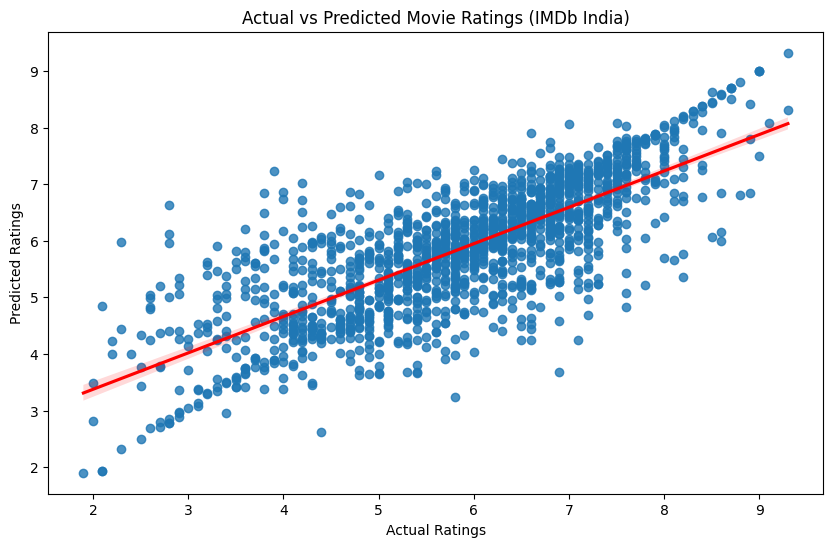

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plotting Actual vs Predicted Ratings
plt.figure(figsize=(10, 6))
sns.regplot(x=y_test, y=y_pred, line_kws={"color": "red"})
plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")
plt.title("Actual vs Predicted Movie Ratings (IMDb India)")
plt.show()